In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tùy chỉnh giao diện biểu đồ cho đẹp mắt
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("--- KHỐI 1: TẢI DỮ LIỆU & TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN ---")

# 1. Tải file dữ liệu sạch
clean_data_path = r'D:\Intern VSF\Data\yellow_tripdata_2026-01_CLEANED.parquet'
df = pd.read_parquet(clean_data_path)
print(f"Đã tải thành công {len(df):,} dòng dữ liệu sạch.")

# 2. Trích xuất (Feature Engineering) các mốc thời gian
# Lưu ý: Cột tpep_pickup_datetime hiện tại đã được pandas hiểu là định dạng datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek # 0=Thứ 2, 6=Chủ nhật
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date

# Map tên Thứ trong tuần cho dễ đọc khi vẽ biểu đồ
day_names = {0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4', 3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'Chủ Nhật'}
df['day_name'] = df['pickup_dayofweek'].map(day_names)

# Phân loại Ngày thường (Weekday) vs Cuối tuần (Weekend)
df['is_weekend'] = df['pickup_dayofweek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Hiển thị thử 5 dòng kết quả để nghiệm thu
print("\n=> 5 dòng đầu của các cột thời gian vừa tạo:")
display(df[['tpep_pickup_datetime', 'pickup_hour', 'day_name', 'is_weekend', 'pickup_date']].head())


--- KHỐI 1: TẢI DỮ LIỆU & TRÍCH XUẤT ĐẶC TRƯNG THỜI GIAN ---
Đã tải thành công 3,499,217 dòng dữ liệu sạch.

=> 5 dòng đầu của các cột thời gian vừa tạo:


,tpep_pickup_datetime,pickup_hour,day_name,is_weekend,pickup_date
0,2026-01-01 00:54:04,0,Thứ 5,Weekday,2026-01-01
1,2026-01-01 00:15:22,0,Thứ 5,Weekday,2026-01-01
2,2026-01-01 00:47:11,0,Thứ 5,Weekday,2026-01-01
3,2026-01-01 00:17:54,0,Thứ 5,Weekday,2026-01-01
4,2026-01-01 00:34:14,0,Thứ 5,Weekday,2026-01-01


In [2]:
# In ra danh sách toàn bộ các cột hiện có trong Dataframe
print("DANH SÁCH CÁC CỘT HIỆN TẠI:")
print(df.columns.tolist())

# Hiển thị tất cả các cột của 3 dòng đầu tiên để soi kỹ dữ liệu
pd.set_option('display.max_columns', None) # Lệnh này ép Jupyter hiện TẤT CẢ các cột (không bị ẩn bằng dấu ...)
display(df.head(3))



DANH SÁCH CÁC CỘT HIỆN TẠI:
['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee', 'pu_LocationID', 'pu_Borough', 'pu_Zone', 'pu_service_zone', 'do_LocationID', 'do_Borough', 'do_Zone', 'do_service_zone', 'vendor_name', 'ratecode_name', 'hour_of_day', 'day_of_week', 'trip_duration_minutes', 'speed_mph', 'pickup_hour', 'pickup_dayofweek', 'pickup_date', 'day_name', 'is_weekend']


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,pu_LocationID,pu_Borough,pu_Zone,pu_service_zone,do_LocationID,do_Borough,do_Zone,do_service_zone,vendor_name,ratecode_name,hour_of_day,day_of_week,trip_duration_minutes,speed_mph,pickup_hour,pickup_dayofweek,pickup_date,day_name,is_weekend
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.0,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00,239,Manhattan,Upper West Side South,Yellow Zone,238,Manhattan,Upper West Side North,Yellow Zone,Curb Mobility,Standard rate,0,3,5.55,10.486486,0,3,2026-01-01,Thứ 5,Weekday
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.0,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75,142,Manhattan,Lincoln Square East,Yellow Zone,209,Manhattan,Seaport,Yellow Zone,Curb Mobility,Standard rate,0,3,42.80,7.822430,0,3,2026-01-01,Thứ 5,Weekday
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.2,1.0,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75,144,Manhattan,Little Italy/NoLiTa,Yellow Zone,137,Manhattan,Kips Bay,Yellow Zone,Curb Mobility,Standard rate,0,3,13.60,10.279412,0,3,2026-01-01,Thứ 5,Weekday


In [3]:
# Danh sách các cột bị trùng lặp logic
cols_to_drop = ['pu_LocationID', 'do_LocationID', 'hour_of_day', 'day_of_week']

# Lệnh XÓA (Drop)
df = df.drop(columns=cols_to_drop)

print(f"Đã xóa thành công {len(cols_to_drop)} cột bị trùng lặp!")
print(f"Số cột hiện tại đã gọn gàng hơn: {len(df.columns)} cột.")


Đã xóa thành công 4 cột bị trùng lặp!
Số cột hiện tại đã gọn gàng hơn: 35 cột.


--- KHỐI 2: PHÂN TÍCH THEO KHUNG GIỜ TRONG NGÀY (HOUR-OF-DAY) ---


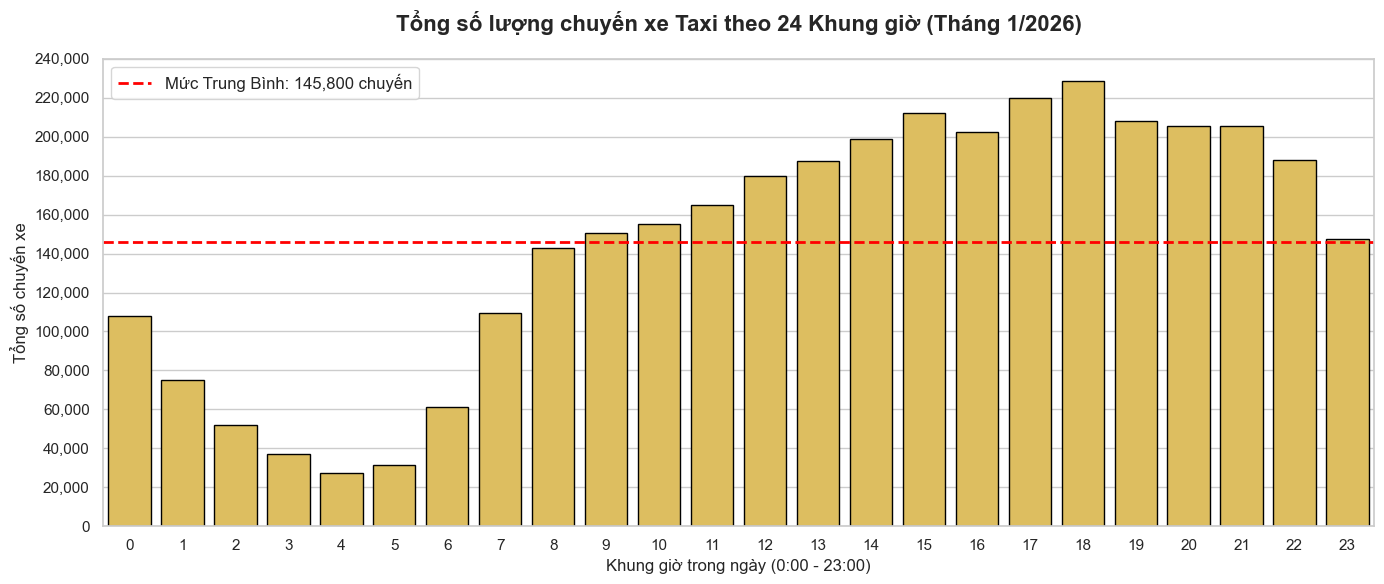

In [4]:
print("--- KHỐI 2: PHÂN TÍCH THEO KHUNG GIỜ TRONG NGÀY (HOUR-OF-DAY) ---")

# Tính tổng số chuyến xe theo từng giờ
hourly_counts = df.groupby('pickup_hour').size().reset_index(name='trip_count')

# Khởi tạo khung vẽ biểu đồ
plt.figure(figsize=(14, 6))

# Vẽ biểu đồ Cột (Barplot) màu Vàng đặc trưng của Taxi
sns.barplot(data=hourly_counts, x='pickup_hour', y='trip_count', color='#F2C84B', edgecolor='black')

# Trang trí tiêu đề và trục
plt.title('Tổng số lượng chuyến xe Taxi theo 24 Khung giờ (Tháng 1/2026)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Khung giờ trong ngày (0:00 - 23:00)', fontsize=12)
plt.ylabel('Tổng số chuyến xe', fontsize=12)
plt.xticks(range(0, 24))
plt.yticks(range(0, int(hourly_counts['trip_count'].max()) + 20000, 20000))

# Thêm 1 đường gạch ngang màu đỏ đứt nét để thể hiện Mức Trung bình (Average)
avg_trips = hourly_counts['trip_count'].mean()
plt.axhline(avg_trips, color='red', linestyle='--', linewidth=2, label=f'Mức Trung Bình: {int(avg_trips):,} chuyến')
plt.legend(fontsize=12)

# Định dạng nhãn trục Y có dấu phẩy (vd: 100,000)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


--- KHỐI 3: PHÂN TÍCH THEO THỨ TRONG TUẦN (DAY-OF-WEEK) ---


C:\Users\minhh\AppData\Local\Temp\ipykernel_30144\16099692.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=day_counts, x='day_name', y='trip_count', ax=ax[0], palette=['#4A90E2']*5 + ['#F5A623']*2)
C:\Users\minhh\AppData\Local\Temp\ipykernel_30144\16099692.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg_weekend_vs_weekday, x='is_weekend', y='daily_trips', ax=ax[1], palette={'Weekday': '#4A90E2', 'Weekend': '#F5A623'})


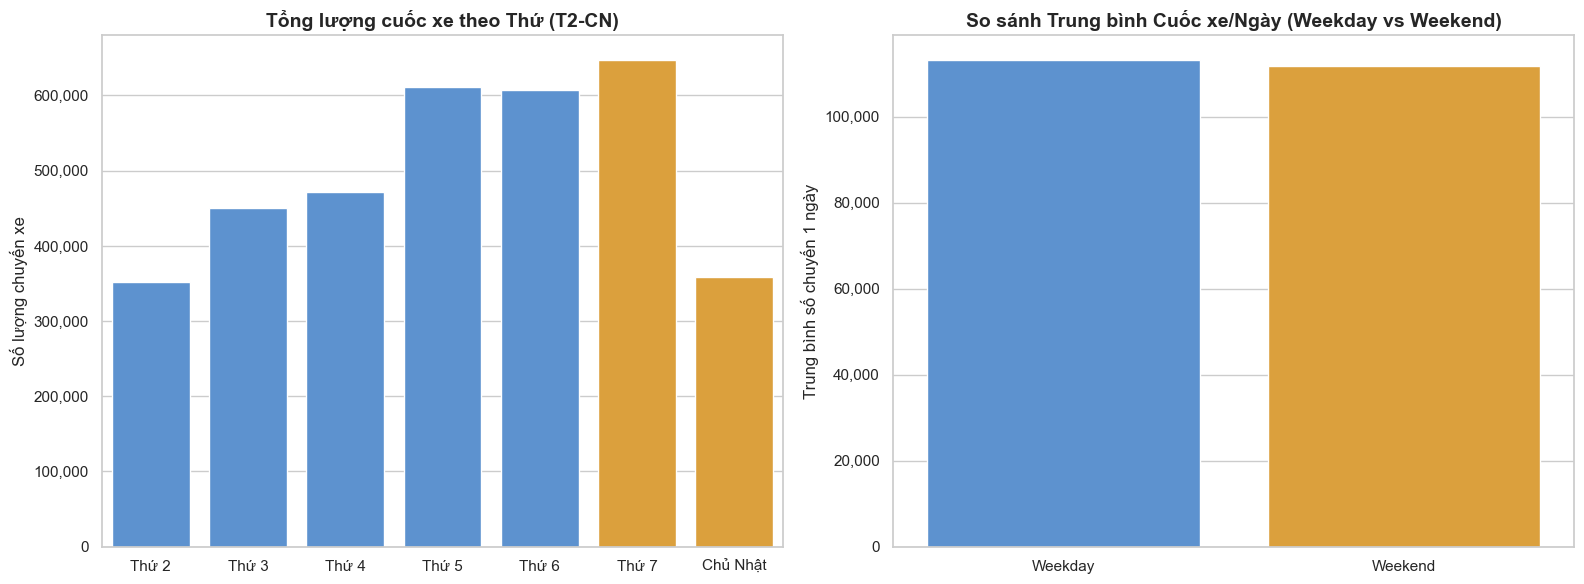

In [5]:
print("--- KHỐI 3: PHÂN TÍCH THEO THỨ TRONG TUẦN (DAY-OF-WEEK) ---")

# 1. Tính tổng số chuyến theo từng Thứ
# Đảm bảo thứ tự hiển thị đúng từ Thứ 2 đến Chủ Nhật
order_days = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'Chủ Nhật']
day_counts = df.groupby('day_name').size().reindex(order_days).reset_index(name='trip_count')

# Khởi tạo khung biểu đồ
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Số chuyến theo từng Thứ
sns.barplot(data=day_counts, x='day_name', y='trip_count', ax=ax[0], palette=['#4A90E2']*5 + ['#F5A623']*2)
ax[0].set_title('Tổng lượng cuốc xe theo Thứ (T2-CN)', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Số lượng chuyến xe', fontsize=12)
ax[0].set_xlabel('')
ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Biểu đồ 2: So sánh Trung bình Ngày thường vs Cuối tuần
# Vì T2-T6 có 5 ngày, T7-CN có 2 ngày, nên phải tính TRUNG BÌNH MỖI NGÀY mới công bằng
daily_avg = df.groupby(['pickup_date', 'is_weekend']).size().reset_index(name='daily_trips')
avg_weekend_vs_weekday = daily_avg.groupby('is_weekend')['daily_trips'].mean().reset_index()

sns.barplot(data=avg_weekend_vs_weekday, x='is_weekend', y='daily_trips', ax=ax[1], palette={'Weekday': '#4A90E2', 'Weekend': '#F5A623'})
ax[1].set_title('So sánh Trung bình Cuốc xe/Ngày (Weekday vs Weekend)', fontsize=14, fontweight='bold')
ax[1].set_ylabel('Trung bình số chuyến 1 ngày', fontsize=12)
ax[1].set_xlabel('')
ax[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()


--- KHỐI 4: PHÂN TÍCH XU HƯỚNG THEO NGÀY (DAILY TREND) ---


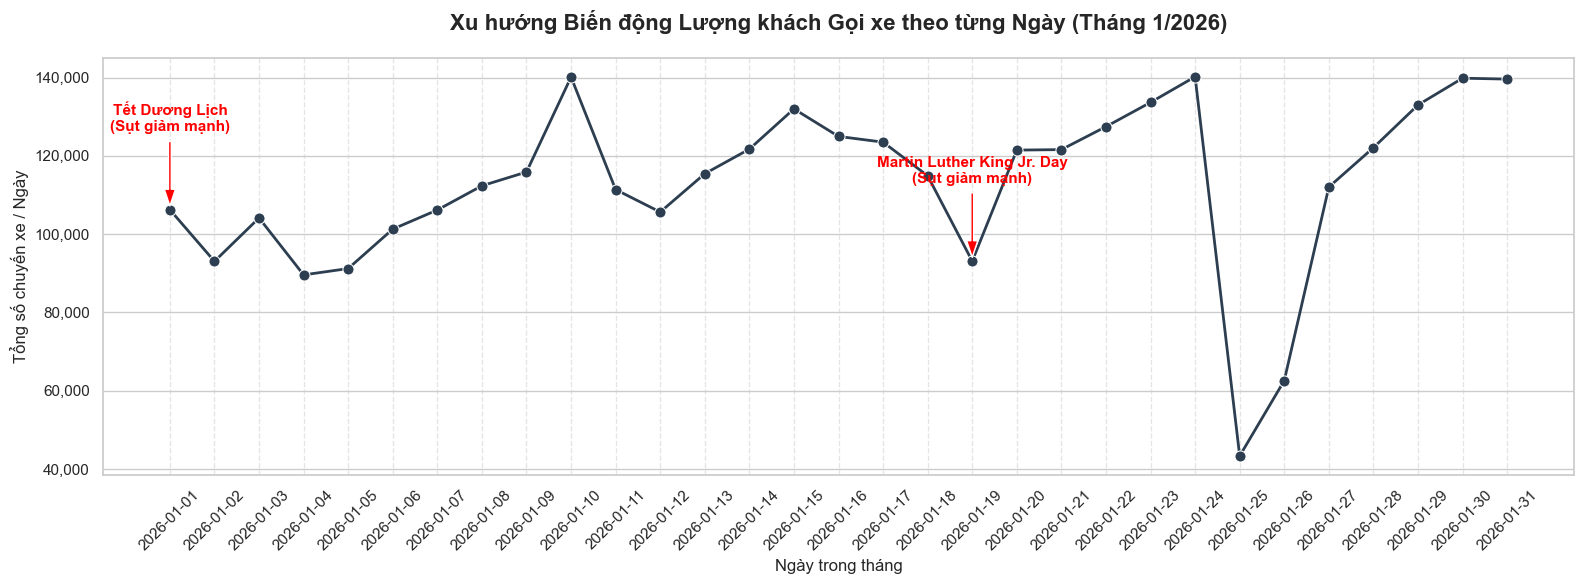

In [6]:
import datetime

print("--- KHỐI 4: PHÂN TÍCH XU HƯỚNG THEO NGÀY (DAILY TREND) ---")

# Tính tổng số chuyến xe theo từng ngày
daily_trend = df.groupby('pickup_date').size().reset_index(name='trip_count')

# Khởi tạo khung biểu đồ
plt.figure(figsize=(16, 6))

# Vẽ biểu đồ Line (Đường thẳng) với các điểm đánh dấu (marker='o')
sns.lineplot(data=daily_trend, x='pickup_date', y='trip_count', marker='o', markersize=8, linewidth=2, color='#2C3E50')

# Gắn nhãn đỏ chỉ mũi tên vào 2 ngày Lễ lớn trong Tháng 1/2026
holidays = [datetime.date(2026, 1, 1), datetime.date(2026, 1, 19)]
holiday_names = ['Tết Dương Lịch', 'Martin Luther King Jr. Day']

for holiday, name in zip(holidays, holiday_names):
    if holiday in daily_trend['pickup_date'].values:
        holiday_trips = daily_trend[daily_trend['pickup_date'] == holiday]['trip_count'].values[0]
        plt.annotate(f'{name}\n(Sụt giảm mạnh)', 
                     xy=(holiday, holiday_trips), 
                     xytext=(holiday, holiday_trips + 20000), # Đưa chữ lên cao hơn điểm marker
                     arrowprops=dict(facecolor='red', shrink=0.05, width=2, headwidth=8),
                     fontsize=11, color='red', weight='bold', ha='center')

# Trang trí
plt.title('Xu hướng Biến động Lượng khách Gọi xe theo từng Ngày (Tháng 1/2026)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Ngày trong tháng', fontsize=12)
plt.ylabel('Tổng số chuyến xe / Ngày', fontsize=12)

# Ép hiển thị đủ 31 ngày và xoay chéo chữ để không đè lên nhau
plt.xticks(daily_trend['pickup_date'], rotation=45)

# Định dạng nhãn trục Y có dấu phẩy
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.grid(axis='x', linestyle='--', alpha=0.5) # Kẻ đường gióng mờ
plt.tight_layout()
plt.show()
